In [4]:
%pip install pyod
from pyod.utils.data import generate_data
import matplotlib.pyplot as plt

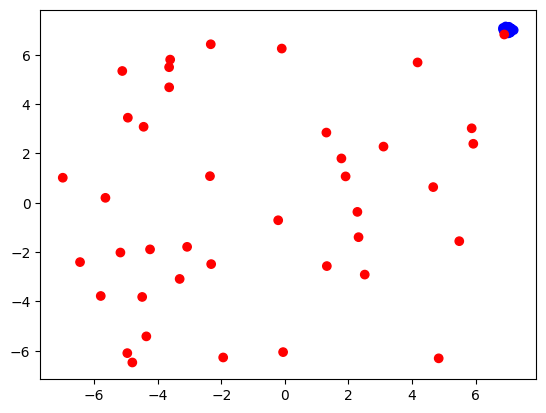

In [10]:
x_train, x_test, y_train, y_test = generate_data(400, 100, 2, 0.1)
c = ['red' if l == 1 else 'blue' for l in y_train]
plt.scatter(x_train[:, 0], x_train[:, 1], c=c)

Train confusion matrix
[[360   0]
 [  0  40]]
Test confusion matrix
[[90  0]
 [ 0 10]]
Train balanced acc
1.0
Test balanced acc
1.0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:95: FutureWarning: Function fit_predict is deprecated
  warnings.warn(msg, category=FutureWarning)
/usr/local/lib/python3.12/dist-packages/pyod/models/base.py:554: UserWarning: y should not be presented in unsupervised learning.
  warnings.warn(


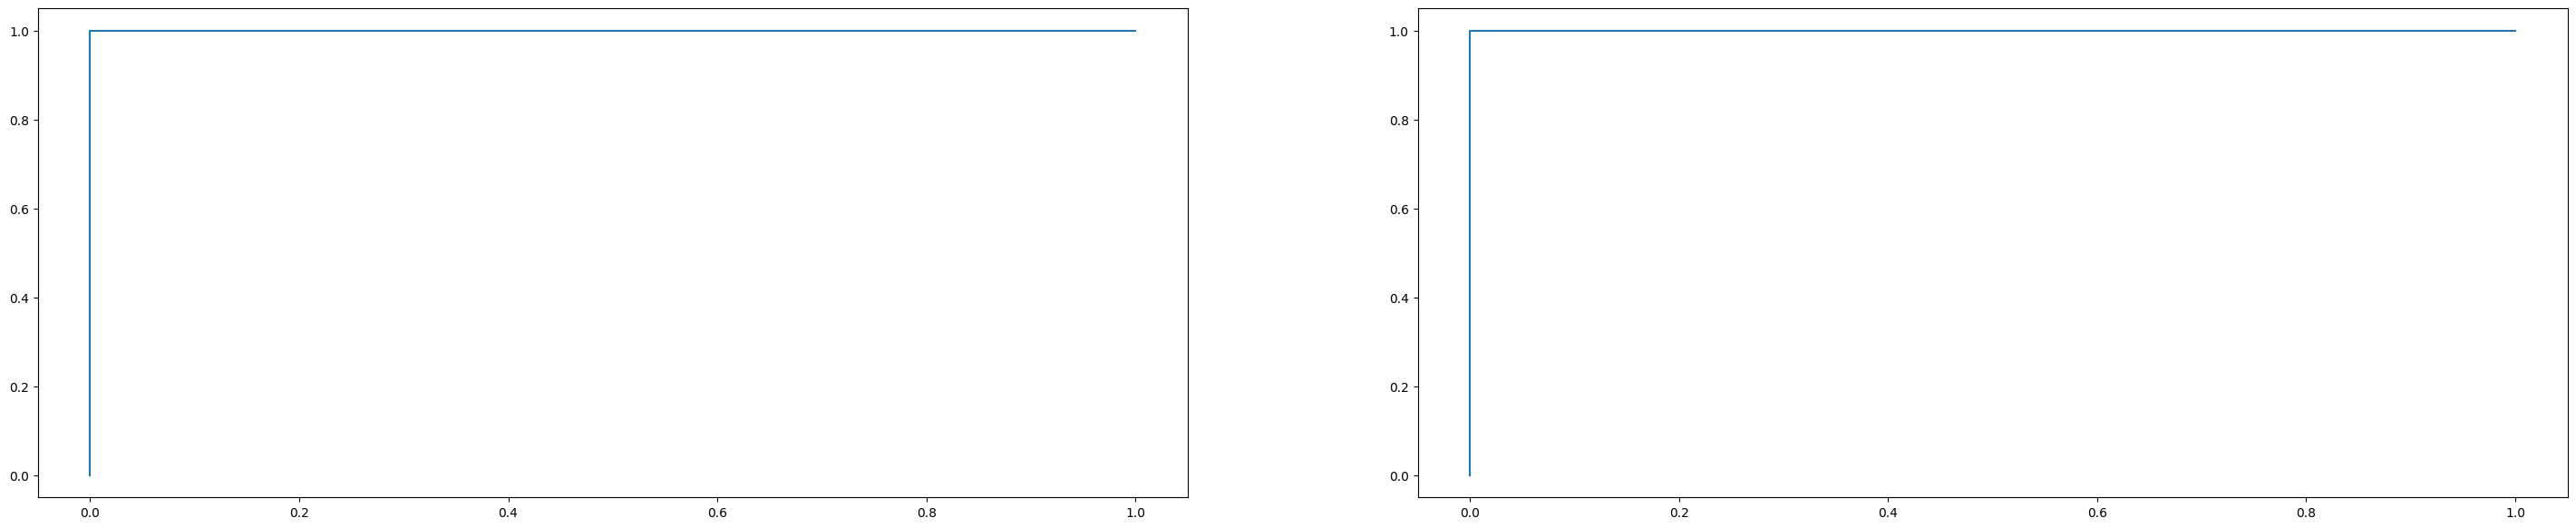

In [16]:
from pyod.models.knn import KNN
from sklearn.metrics import confusion_matrix, balanced_accuracy_score, roc_curve

model = KNN(contamination= 0.1)
y_pred_train = model.fit_predict(x_train, y_train)
y_pred_test = model.predict(x_test)

y_train_score = model.decision_function(x_train)
y_test_score = model.decision_function(x_test)

print("Train confusion matrix")
print(confusion_matrix(y_train, y_pred_train))
print("Test confusion matrix")
print(confusion_matrix(y_test, y_pred_test))

print("Train balanced acc")
print(balanced_accuracy_score(y_train, y_pred_train))
print("Test balanced acc")
print(balanced_accuracy_score(y_test, y_pred_test))

fig, axes = plt.subplots(1, 2, figsize=(36, 7))
axes = axes.flatten()

fpr_train, tpr_train, thresholds = roc_curve(y_train, y_train_score)
axes[0].plot(fpr_train, tpr_train)

fpr_test, tpr_test, thresholds = roc_curve(y_test, y_test_score)
axes[1].plot(fpr_test, tpr_test)




In [82]:
import numpy as np
x_train_1d, x_test_1d, y_train_1d, y_test_1d = generate_data(1000, 0, 1, 0.1)

mean = np.mean(x_train)
std = np.std(x_train)

z_score = np.abs(x_train_1d - mean) / std

thresh = np.quantile(z_score, 0.9)

preds = (z_score >= thresh).astype(np.int32)

print(balanced_accuracy_score(y_train_1d, preds))



0.9333333333333333


In [22]:
def is_pos_def(x):
    return np.all(np.linalg.eigvals(x) > 0)

In [76]:
data = np.random.normal(size=(1000, 3))
mean = np.array([0, 0, 0])
cov = np.array(
    [[1.0, 0.0, 0.0],
    [0.0, 1.0, 0.2],
    [0.1, 1.0, 0.3]]
)
cov = cov.T @ cov

z_score = []
L = np.linalg.cholesky(cov)

for data_i in range(data.shape[0]):
  data[data_i] = (L @ data[data_i]) + mean

for d in data:
  y = np.linalg.solve(L, d)
  z_score.append(np.linalg.norm(y))

z_score = np.array(z_score)

thresh = np.quantile(z_score, 0.9)

preds = (z_score >= thresh).astype(np.int32)

print(balanced_accuracy_score(y_train_1d, preds))

0.5
